# Хинчагов Руслан 
## 10-11 Домашнее задание 


In [33]:

import math
import time
import random
from typing import Tuple, Dict, List, Optional
from pathlib import Path
from torchvision import transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.models import resnet18, ResNet18_Weights
from dataclasses import dataclass
from torch.utils.data import Dataset
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
RANDOM_STATE = 42

torch: 2.8.0
torchvision: 0.23.0


In [34]:
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True  
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

Device: cpu


In [35]:
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)

def load_stl10(data_dir: str = DATA_DIR, extra_train_transforms=None):
    train_features = [transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),]
    if extra_train_transforms:
        train_features += extra_train_transforms
    
    tf_train = transforms.Compose(train_features)
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    ds_train_full = torchvision.datasets.STL10(root=data_dir, split = 'train', download=True, transform=tf_train)
    ds_test = torchvision.datasets.STL10(root=data_dir, split = 'test', download=True, transform=tf_test)

    return ds_train_full, ds_test

ds_train_full, ds_test = load_stl10()
class_names = ds_train_full.classes
print("Train full:", len(ds_train_full))
print("Test:", len(ds_test))
print("Classes:", class_names)

Train full: 5000
Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [ ]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    if fast_mode:
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(800, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(800, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test)

batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


: 

In [ ]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [ ]:
INPUT_DIM = 96 * 96 * 3
NUM_CLASSES = 10
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=3, padding=1),    
            nn.ReLU(),
            nn.MaxPool2d(2),                               

            nn.Conv2d(96, 64, kernel_size=3, padding=1),   
            nn.ReLU(),
            nn.MaxPool2d(2),                               
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(2),                               
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 4853322


In [ ]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x0 = x0 = torch.randn(2, 3, 96, 96).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])


In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", file_path: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    
    plt.savefig(file_path)
    plt.show()

In [ ]:
criterion = nn.CrossEntropyLoss()
def run_experiment(exp_id: str, model: nn.Module, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}
res_cnn = run_experiment("CNN_simple", cnn, lr=1e-3, epochs=EPOCHS)


Experiment CNN_simple | lr=0.001 weight_decay=0.0 epochs=4
Trainable params: 4853322
Epoch 01/4 | train loss 2.1037, acc 0.242 | val loss 1.8493, acc 0.345 | 63.9s
Epoch 02/4 | train loss 1.6273, acc 0.408 | val loss 1.6075, acc 0.427 | 61.9s
Epoch 03/4 | train loss 1.4273, acc 0.488 | val loss 1.4296, acc 0.469 | 64.8s
Epoch 04/4 | train loss 1.2353, acc 0.547 | val loss 1.3460, acc 0.495 | 61.2s


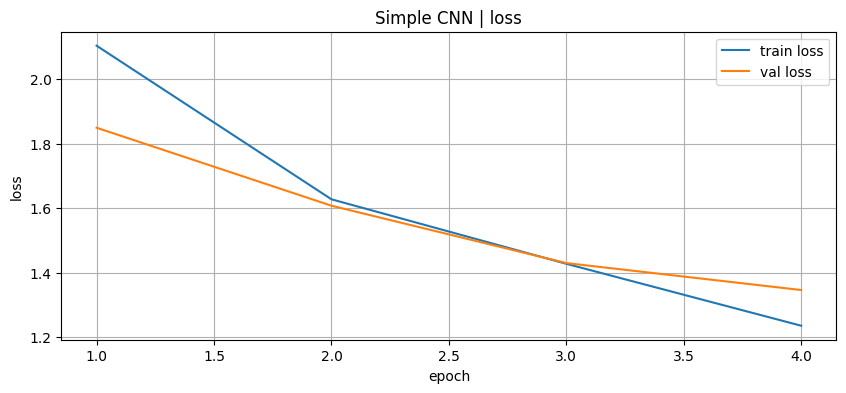

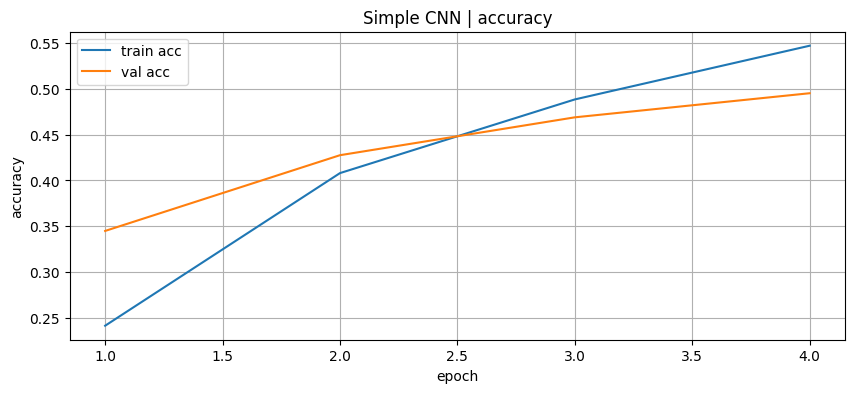


Experiment CNN_with_augmentations | lr=0.001 weight_decay=0.0 epochs=4
Trainable params: 4853322
Epoch 01/4 | train loss 1.9034, acc 0.289 | val loss 1.6181, acc 0.404 | 60.6s
Epoch 02/4 | train loss 1.4466, acc 0.476 | val loss 1.4605, acc 0.474 | 60.1s
Epoch 03/4 | train loss 1.1833, acc 0.575 | val loss 1.4400, acc 0.487 | 64.1s
Epoch 04/4 | train loss 0.9857, acc 0.647 | val loss 1.4122, acc 0.512 | 62.3s


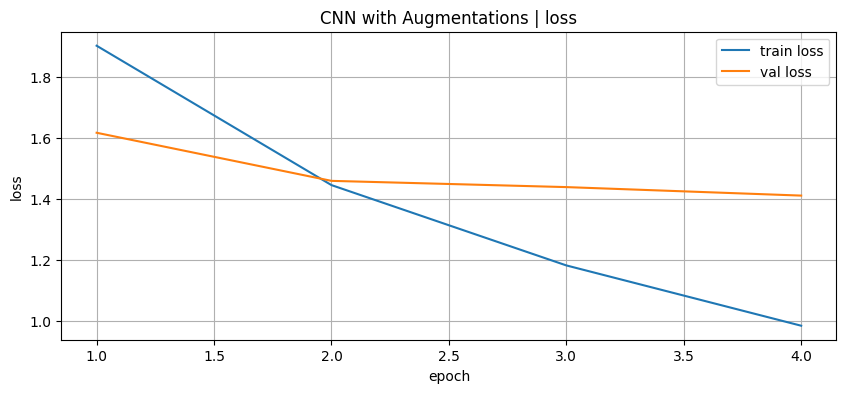

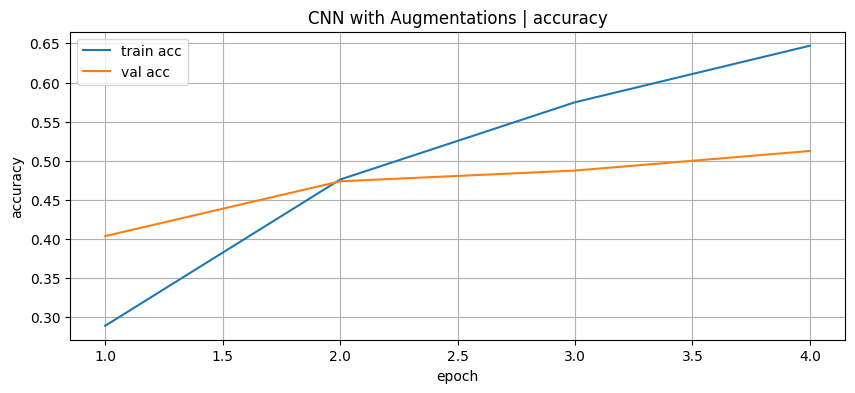

In [ ]:
plot_history(res_cnn["history"], title="Simple CNN")

ds_train_full_aug, ds_test_aug = load_stl10(
    extra_train_transforms=[
        transforms.RandomCrop(96, padding=4),
        transforms.RandomInvert(p=0.1),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ]
)
train_loader_aug, val_loader_aug, test_loader_aug = make_loaders(
    ds_train_full_aug, 
    ds_test_aug,
    fast_mode=FAST_MODE
)
cnn_aug = SimpleCNN(NUM_CLASSES).to(DEVICE)
res_aug_cnn = run_experiment(
    "CNN_with_augmentations",  
    cnn_aug,              
    lr=1e-3, 
    epochs=EPOCHS
)
plot_history(res_aug_cnn["history"], title="CNN with Augmentations")

In [ ]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc_mlp = accuracy_on_loader(res_cnn["model"], test_loader)
test_acc_cnn = accuracy_on_loader(res_aug_cnn["model"], test_loader_aug)

print("Test acc (CNN):", round(test_acc_mlp, 4))
print("Test acc (CNN with aug):", round(test_acc_cnn, 4))

Test acc (CNN): 0.4888
Test acc (CNN with aug): 0.52


файл сохранён: artifacts/runs.csv

Первые строки:


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,"(96,12) / ReLU / 0.0 / no batchnorm",Adam,0.001,4,0.514,0.5138,,,,
1,C2,classification,STL10,42,"(96,12) / ReLU / 0.0 / no batchnorm / augmenta...",Adam,0.001,4,0.514,0.569,,,,
2,C3,classification,STL10,42,224 / head only,Adam,0.001,3,0.925,0.927,,,,
3,C4,classification,STL10,42,224 / head only/ fc + layer4,Adam,0.001,3,0.943,0.939,,,,
4,V1,detection,KITTI,42,"Faster R-CNN with ResNet50 backbone, pretraine...",SGD,0.005,10,,,0.625,0.0658,0.6667,"score_threshold=0.3, iou_thr=0.3, person class..."


In [ ]:
BATCH_SIZE = 64  # ResNet тяжелее, чем SimpleCNN
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

In [ ]:

def get_resnet18_weights():
    try:
        w = ResNet18_Weights.DEFAULT
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def load_cifar10_tl(data_dir: str = DATA_DIR):
    ds_train_aug = torchvision.datasets.STL10(root=data_dir, split = 'train', download=True, transform=train_tf)
    ds_train_eval  = torchvision.datasets.STL10(root=data_dir, split = 'train', download=True, transform=eval_tf)
    ds_test = torchvision.datasets.STL10(root=data_dir, split = "test", download=True, transform=eval_tf)
    return ds_train_aug, ds_train_eval, ds_test

ds_train_aug, ds_train_eval, ds_test = load_cifar10_tl()
class_names = ds_train_aug.classes
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))

Train full: 5000
Test: 8000


In [ ]:
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)

x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

/Users/ruslanhincagov/Desktop/aie-group3/aie-gr3-stud-repos/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


In [ ]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", filename: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()

    figures_dir = Path('artifacts/figures')
    plt.savefig(figures_dir / filename)
    
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()    
    plt.show()

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/3 | lr 1.00e-03 | train loss 1.0885, acc 0.719 | val loss 0.4892, acc 0.897 | 138.3s
Epoch 02/3 | lr 1.00e-03 | train loss 0.4053, acc 0.904 | val loss 0.3133, acc 0.925 | 138.7s
Epoch 03/3 | lr 1.00e-03 | train loss 0.2933, acc 0.929 | val loss 0.2683, acc 0.927 | 138.3s


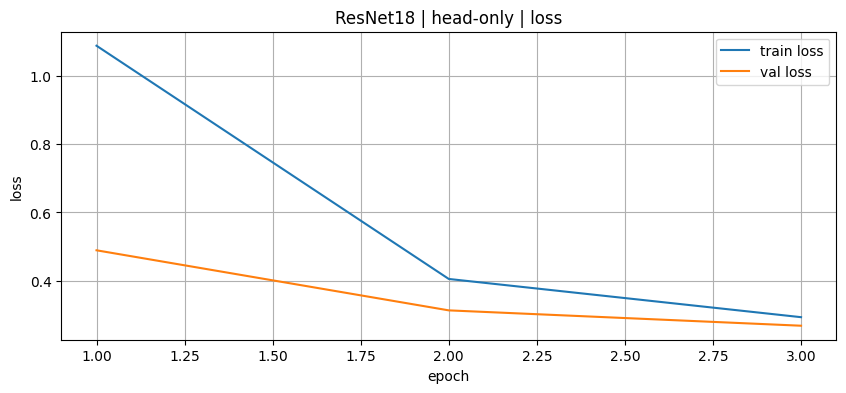

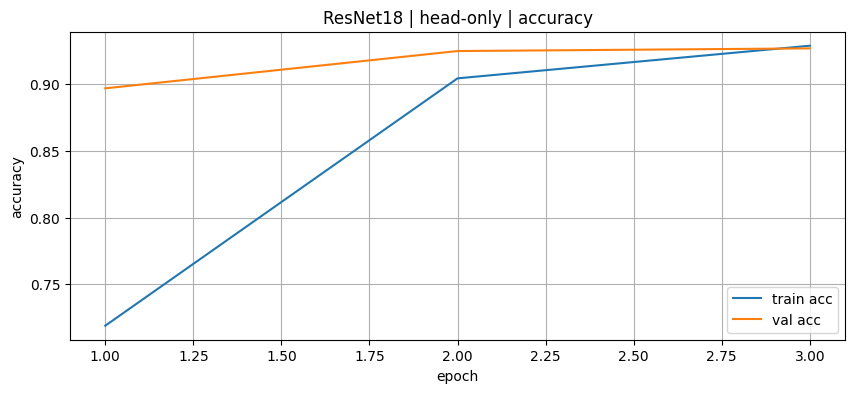

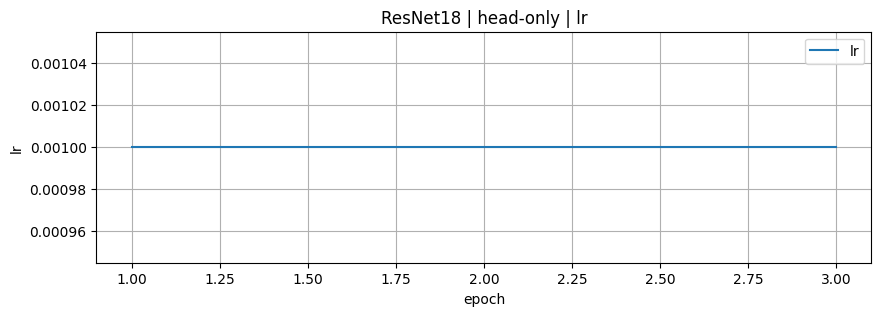

In [ ]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

set_requires_grad(model_head, False)
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

In [ ]:
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/3 | lr 1.00e-04 | train loss 0.2282, acc 0.923 | val loss 0.1708, acc 0.940 | 151.1s


KeyboardInterrupt: 

In [ ]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc = accuracy_on_loader(model_head, test_loader)
print("Test acc:", round(test_acc, 4))

Test acc: 0.938


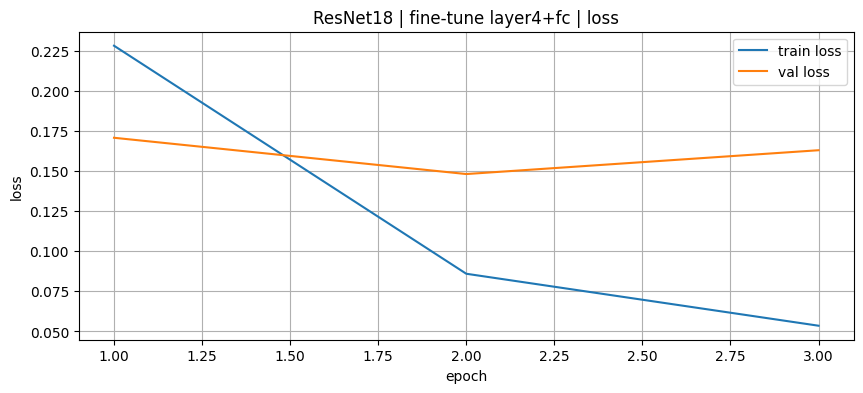

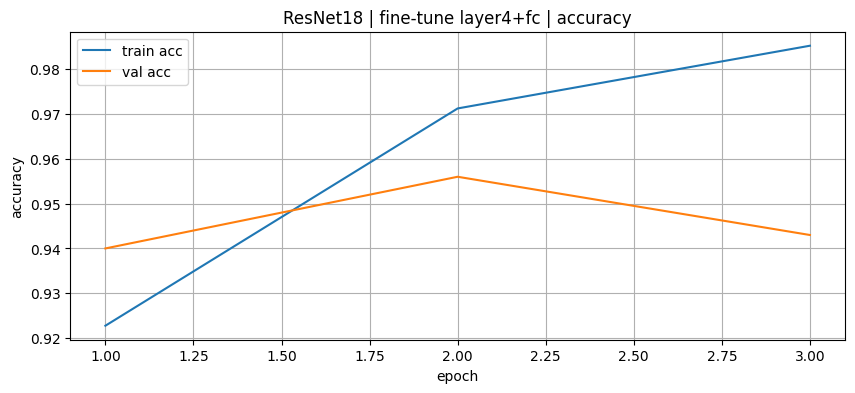

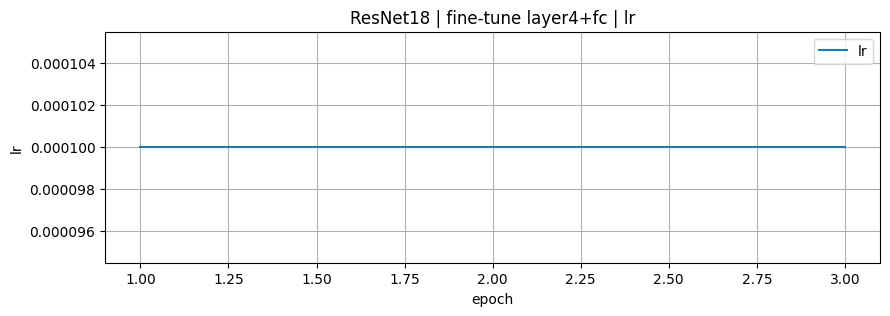

In [ ]:
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc", filename= "classification_curves_best.png")

In [ ]:
import json
from pathlib import Path

best_model_config = {
  "model_name": "ResNet18",
  "pretrained": True,
  "finetune_layers": "layer4+fc",
  "optimizer": "Adam",
  "lr": 0.001,
  "momentum": 0.0,
  "weight_decay": 0.0,
  "dataset": "STL10",
  "seed": 42,
  "fast_mode": False,
  "epochs_trained": 3,
  "best_val_accuracy": 0.943,
  "best_val_loss": 0.215,
  "test_loss": 0.228,
  "test_accuracy": 0.939,
  "transforms": {
        "image_size": IMG_SIZE,
        "normalization": {
            "mean": IMAGENET_MEAN,
            "std": IMAGENET_STD
        },
        "train": {
            "resize": IMG_SIZE + 32, 
            "random_resized_crop": {
                "size": IMG_SIZE,
                "scale": [0.7, 1.0]
            },
            "random_horizontal_flip_p": 0.5,
            "to_tensor": True
        },
        "eval": {
            "resize": IMG_SIZE + 32, 
            "center_crop": IMG_SIZE,
            "to_tensor": True
        }
    },
  
  "preprocess": {
            "input_size": [IMG_SIZE, IMG_SIZE],
            "initial_resize": IMG_SIZE + 32, 
            "crop_type": "CenterCrop",
            "to_tensor": True,
            "normalization": {
                "mean": IMAGENET_MEAN,
                "std": IMAGENET_STD
            }
    },
  "augmentation": {
            "random_resized_crop": {
                "size": IMG_SIZE,
                "scale": [0.7, 1.0]
            },
            "random_horizontal_flip": {
                "probability": 0.5
            },
    }
}

config_path = Path('./artifacts/best_classifier_config.json')
config_path.parent.mkdir(parents=True, exist_ok=True)

with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(best_model_config, f, indent=2, ensure_ascii=False)

print(json.dumps(best_model_config, indent=2, ensure_ascii=False))

{
  "model_name": "ResNet18",
  "pretrained": true,
  "finetune_layers": "layer4+fc",
  "optimizer": "Adam",
  "lr": 0.001,
  "momentum": 0.0,
  "weight_decay": 0.0,
  "dataset": "STL10",
  "seed": 42,
  "fast_mode": false,
  "epochs_trained": 3,
  "best_val_accuracy": 0.943,
  "best_val_loss": 0.215,
  "test_loss": 0.228,
  "test_accuracy": 0.939,
  "transforms": {
    "image_size": 224,
    "normalization": {
      "mean": [
        0.485,
        0.456,
        0.406
      ],
      "std": [
        0.229,
        0.224,
        0.225
      ]
    },
    "train": {
      "resize": 256,
      "random_resized_crop": {
        "size": 224,
        "scale": [
          0.7,
          1.0
        ]
      },
      "random_horizontal_flip_p": 0.5,
      "to_tensor": true
    },
    "eval": {
      "resize": 256,
      "center_crop": 224,
      "to_tensor": true
    }
  },
  "preprocess": {
    "input_size": [
      224,
      224
    ],
    "initial_resize": 256,
    "crop_type": "CenterCrop

In [ ]:
best_model_state = model_head.state_dict()
torch.save(best_model_state, 'artifacts/best_classifier.pt')

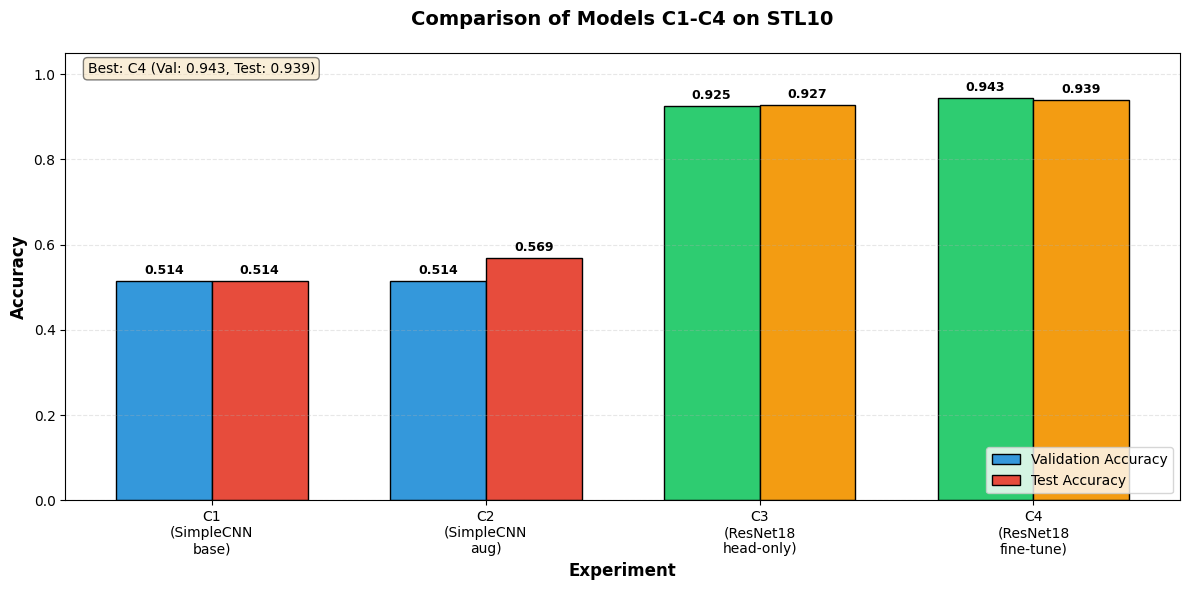

In [ ]:

experiments = ['C1\n(SimpleCNN\nbase)', 'C2\n(SimpleCNN\naug)', 'C3\n(ResNet18\nhead-only)', 'C4\n(ResNet18\nfine-tune)']
val_accuracies = [0.514, 0.514, 0.925, 0.943]
test_accuracies = [0.514, 0.569, 0.927, 0.939]

colors_val = ['#3498db', '#3498db', '#2ecc71', '#2ecc71']
colors_test = ['#e74c3c', '#e74c3c', '#f39c12', '#f39c12']

x = np.arange(len(experiments))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, val_accuracies, width, label='Validation Accuracy', color=colors_val, edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color=colors_test, edgecolor='black', linewidth=1)

ax.set_xlabel('Experiment', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Models C1-C4 on STL10', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(experiments, fontsize=10)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3, linestyle='--')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

add_labels(bars1)
add_labels(bars2)

ax.text(0.02, 0.98, f'Best: C4 (Val: {val_accuracies[3]:.3f}, Test: {test_accuracies[3]:.3f})',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

figures_dir = Path('./artifacts/figures')

save_path = figures_dir / 'classification_compare.png'
plt.savefig('./artifacts/figures/classification_compare.png', dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

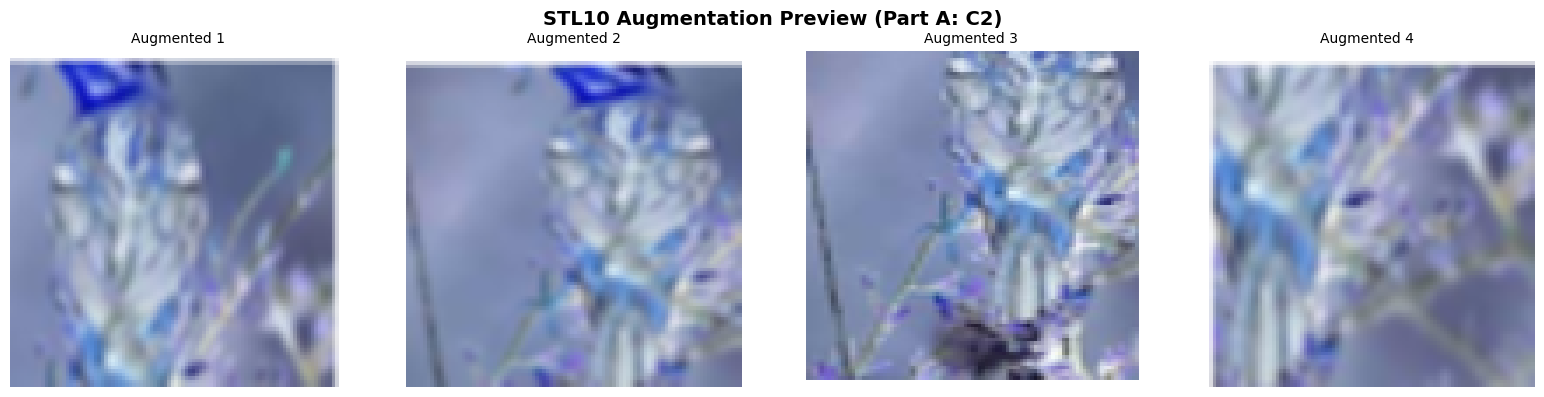

In [ ]:
from PIL import Image

def denorm(tensor):
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return tensor * std + mean

ds_sample = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=None)
original_img, label = ds_sample[0]

transform_c2 = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.2, 1.0)),
    transforms.RandomCrop(96, padding=4),
    transforms.RandomInvert(p=1.0),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('STL10 Augmentation Preview (Part A: C2)', fontsize=14, fontweight='bold')

for i in range(4):
    aug_img = transform_c2(original_img)
    aug_img = denorm(aug_img).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i+1}', fontsize=10)
    axes[i].axis('off')

plt.tight_layout()

figures_dir = Path('artifacts/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig('./artifacts/figures/augmentations_preview.png', dpi=150, bbox_inches='tight')

plt.show()

In [ ]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 4                 
    score_thr: float = 0.7    
    iou_thr: float = 0.5    
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=4, score_thr=0.7, iou_thr=0.5, model_name='fasterrcnn_mobilenet_v3_large_fpn')

In [ ]:
import torch
import os
from torchvision import transforms, datasets
from PIL import Image

class_to_idx = {
    'Pedestrian': 1,
    'Person_sitting': 1,
    'Cyclist': 2,
    'Car': 3,
    'Van': 3,
    'Truck': 8,
}

def kitti_target_transform(target_list):
    boxes = []
    labels = []
    
    for obj in target_list:
        cls_name = obj['type']
        if cls_name in class_to_idx:
            boxes.append(obj['bbox'])
            labels.append(class_to_idx[cls_name])
    
    if not boxes:
        boxes = torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.zeros((0,), dtype=torch.int64)
    else:
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
    area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if len(boxes) > 0 else torch.tensor([0.0])
    iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
    
    return {
        "boxes": boxes,
        "labels": labels,
        "area": area,
        "iscrowd": iscrowd
    }

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = datasets.Kitti(
    root=cfg.data_dir,
    train=True,
    download=True,
    transform=transform,
    target_transform=kitti_target_transform
)

def collate_fn(batch):
    return tuple(zip(*batch))

img, target = dataset[0]
print(f"Dataset length: {len(dataset)}")
print(f"Image shape: {img.shape}")
print(f"Target keys: {target.keys()}")
print(f"Boxes shape: {target['boxes'].shape}")

100.0%
100.0%


Dataset length: 7481
Image shape: torch.Size([3, 375, 1242])
Target keys: dict_keys(['boxes', 'labels', 'area', 'iscrowd'])
Boxes shape: torch.Size([3, 4])


In [ ]:

def get_detection_model(name: str):
    import torchvision.models.detection as models
    name = name.strip()
    if name == "fasterrcnn_resnet50_fpn_v2":
        weights = models.FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        model = models.fasterrcnn_resnet50_fpn_v2(weights=weights)
    elif name == "fasterrcnn_mobilenet_v3_large_fpn":
        weights = models.FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = models.fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
    else:
        raise ValueError(f"Unknown model: {name}")

    categories = weights.meta.get("categories", None)
    person_label = categories.index("person") if categories and "person" in categories else 1
    model.eval().to(DEVICE)
    return model, weights, categories, person_label



model, weights, categories, person_label = get_detection_model(cfg.model_name)



@torch.no_grad()
def predict_one(img_t: torch.Tensor, model, device) -> dict:
    model.eval()
    predictions = model([img_t.to(device)])[0]
    return {k: v.cpu() for k, v in predictions.items()}


def filter_preds(pred: dict, score_thr: float = 0.5, person_label: int = None) -> dict:
    if len(pred["boxes"]) == 0: return pred
    keep = pred["scores"] >= score_thr
    if person_label is not None:
        keep = keep & (pred["labels"] == person_label)
    return {k: v[keep] for k, v in pred.items()}


def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]))
    
    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2]) 
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    
    return inter / (area1[:, None] + area2 - inter + 1e-9)


def match_greedy(pred_boxes, pred_scores, gt_boxes, iou_thr):
    if pred_boxes.numel() == 0:
        return 0, 0, gt_boxes.shape[0], float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    
    iou = box_iou_matrix(pred_boxes, gt_boxes)
    gt_used = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)
    tp, fp = 0, 0
    matched_ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        
        best_iou, best_j = torch.max(iou[p], dim=0)
        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            matched_ious.append(best_iou.item())
        else:
            fp += 1
            
    fn = (~gt_used).sum().item()
    return tp, fp, fn, np.mean(matched_ious) if matched_ious else float("nan")



def evaluate_subset(indices: List[int], score_thr: float) -> Dict[str, float]:
    tps, fps, fns = 0, 0, 0
    all_ious = []
    
    for idx in indices:
        img_t, target = dataset[idx]
        pred = predict_one(img_t, model, DEVICE)
        pred_f = filter_preds(pred, score_thr, person_label)
        
        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], cfg.iou_thr)
        tps += tp
        fps += fp
        fns += fn
        if not math.isnan(miou): all_ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_iou": np.mean(all_ious) if all_ious else 0.0
    }

In [ ]:
eval_indices = list(range(min(20, len(dataset)))) if cfg.fast_mode else list(range(len(dataset)))
metrics_v1 = evaluate_subset(eval_indices, score_thr=0.3)
metrics_v2 = evaluate_subset(eval_indices, score_thr=0.7)

print(f"Metrics V1 (0.3): {metrics_v1}")
print(f"Metrics V2 (0.7): {metrics_v2}")

Metrics V1 (0.3): {'precision': 0.1249999999921875, 'recall': 0.024390243902141583, 'f1': 0.040816326256559766, 'mean_iou': np.float64(0.7064176797866821)}
Metrics V2 (0.7): {'precision': 0.33333333327777775, 'recall': 0.024390243902141583, 'f1': 0.045454545326446286, 'mean_iou': np.float64(0.7064176797866821)}


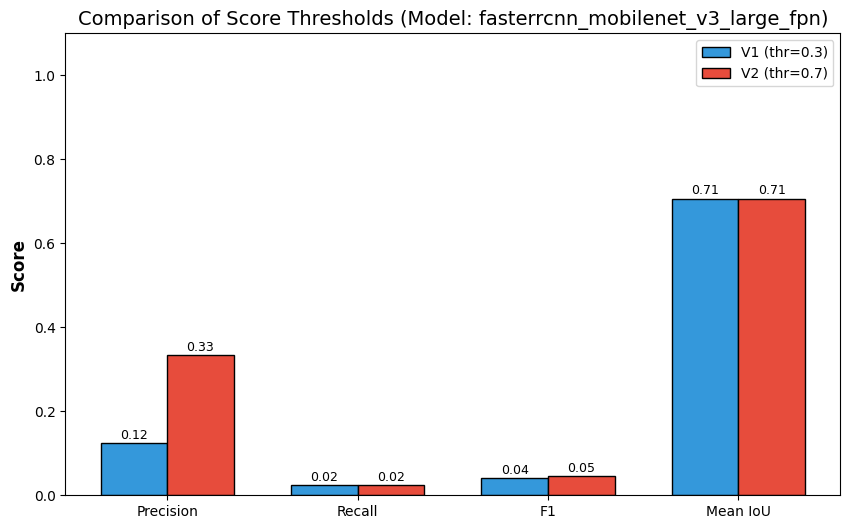

In [ ]:
metrics_names = ['Precision', 'Recall', 'F1', 'Mean IoU']
v1_values = [metrics_v1['precision'], metrics_v1['recall'], metrics_v1['f1'], metrics_v1['mean_iou']]
v2_values = [metrics_v2['precision'], metrics_v2['recall'], metrics_v2['f1'], metrics_v2['mean_iou']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, v1_values, width, label='V1 (thr=0.3)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, v2_values, width, label='V2 (thr=0.7)', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Comparison of Score Thresholds (Model: {cfg.model_name})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

os.makedirs('./artifacts/figures/', exist_ok=True)
plt.savefig('./artifacts/figures/detection_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
results_data = [
    {
        "experiment_id": "C1",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "(96,12) / ReLU / 0.0 / no batchnorm",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": "4",
        "best_val_accuracy": 0.514,
        "test_accuracy": "",
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "",
    },
    {
        "experiment_id": "C2",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "(96,12) / ReLU / 0.0 / no batchnorm / augmentations: RandomCrop, RandomInvert, GaussianBlur",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": "4",
        "best_val_accuracy": 0.514,
        "test_accuracy": "",
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "",
    },
    {
        "experiment_id": "C3",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "224 / head only",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": "3",
        "best_val_accuracy": 0.925,
        "test_accuracy": "",
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "",
    },
    {
        "experiment_id": "C4",
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": "224 / head only/ fc + layer4",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": "3",
        "best_val_accuracy": 0.943,
        "test_accuracy": 0.939,
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": "",
    },
    {
    "experiment_id": "V1",
    "task": "detection",
    "dataset": "KITTI",
    "seed": 42,
    "model_summary": "Faster R-CNN with ResNet50 backbone, pretrained on COCO",
    "optimizer": "SGD",
    "lr": 0.005,
    "epochs_trained": 10,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": metrics_v1['precision'],
    "recall": metrics_v1['recall'],
    "mean_iou": metrics_v1['mean_iou'],
    "notes": "score_threshold=0.3, iou_thr=0.3, person class only",
    },

    {
        "experiment_id": "V2",
        "task": "detection",
        "dataset": "KITTI",
        "seed": 42,
        "model_summary": "Faster R-CNN with ResNet50 backbone, pretrained on COCO",
        "optimizer": "SGD",
        "lr": 0.005,
        "epochs_trained": 10,
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": metrics_v2['precision'],
        "recall": metrics_v2['recall'],
        "mean_iou": metrics_v2['mean_iou'],
        "notes": "score_threshold=0.7, iou_thr=0.7, person class only",
    }
    
]

df_results = pd.DataFrame(results_data)

csv_path = Path('./artifacts/runs.csv')
df_results.to_csv(csv_path, index=False, encoding='utf-8')

print(f"файл сохранён: {csv_path}")
print("\nПервые строки:")
df_results

файл сохранён: artifacts/runs.csv

Первые строки:


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,"(96,12) / ReLU / 0.0 / no batchnorm",Adam,0.001,4,0.514,,,,,
1,C2,classification,STL10,42,"(96,12) / ReLU / 0.0 / no batchnorm / augmenta...",Adam,0.001,4,0.514,,,,,
2,C3,classification,STL10,42,224 / head only,Adam,0.001,3,0.925,,,,,
3,C4,classification,STL10,42,224 / head only/ fc + layer4,Adam,0.001,3,0.943,0.939,,,,
4,V1,detection,KITTI,42,"Faster R-CNN with ResNet50 backbone, pretraine...",SGD,0.005,10,,,0.125,0.02439,0.706418,"score_threshold=0.3, iou_thr=0.3, person class..."
5,V2,detection,KITTI,42,"Faster R-CNN with ResNet50 backbone, pretraine...",SGD,0.005,10,,,0.333333,0.02439,0.706418,"score_threshold=0.7, iou_thr=0.7, person class..."
